In [1]:
import abm
import numpy as np
import pandas as pd
from plotnine import *

In [2]:
model = 'inputs/Models/2compartment_Ab.iqd'

# Simulations

The most flexible method of defining simulation conditions (ie parameter values and dosing schedules) is through the use of parameter, dose, and simulation tables. These tables provide a large degree of flexibility and allow you to modify the model parameters and dosing schedules without editing the model file. 



### Two dosing schedules

One of the greatest strengths of the IQ Analyze simulation environment is the ability to include labels on different parameter sets or dosing regimes. This allows you to simultaneously define and run simulations for mutliple populations. In the first example we will look at the effect of two separate dosing schedules - a single dose and a repeat dose schedule. Pay attention to the dose and simulation tables to see how those schedules are defined.

In [3]:
doses = [0.1, 0.3, 1, 3, 10, 30]
times_repeat = [0, 7, 14, 21, 28]
times_single = [0]

Tdos_repeat = pd.DataFrame({'dose_mpk':doses,
                            'amounts': doses,
                            'times': [times_repeat] * len(list(doses))}).assign(time_unit = 'd', amount_unit = 'mg/kg',
                                                                                route = 'Dose_SC', schedule = 'repeat')
Tdos_single = pd.DataFrame({'dose_mpk':doses,
                            'amounts': doses,
                            'times': [times_single] * len(list(doses))}).assign(time_unit = 'd', amount_unit = 'mg/kg',
                                                                                route = 'Dose_SC', schedule = 'single')

Tdos = pd.concat([Tdos_repeat, Tdos_single])
Tsim = Tdos[['dose_mpk', 'schedule']]

In [4]:
Tpar = pd.read_csv('inputs/Parameters/Parameter.csv')

Tpar = pd.concat([Tpar, pd.DataFrame({'parameter':['Dose_amt_IV', 'Dose_amt_SC'],
                                      'value':[0,0],
                                      'unit':['mg/kg', 'mg/kg'],
                                      'is_fit':[False, False]})])

In [5]:
print('Parameter Table:')
display(Tpar)
print('\n Dose Table:')
display(Tdos)
print('\n Simulation Table:')
display(Tsim)

Parameter Table:


,parameter,unit,value,is_fit,upper_bound,lower_bound
0,Volume_c,L,3.000,False,NaN,NaN
1,Volume_p,L,13.000,False,NaN,NaN
2,MW,kDa,150.000,False,NaN,NaN
3,BW,kg,70.000,False,NaN,NaN
4,Pdist,1,0.300,False,NaN,NaN
5,Tdist,hr,7.000,False,NaN,NaN
6,Thalf,d,28.000,False,NaN,NaN
7,Receptors_c,nM,10.000,False,NaN,NaN
8,Receptors_p,nM,50.000,False,NaN,NaN
9,kon,1/nM/s,0.001,False,NaN,NaN



 Dose Table:


,dose_mpk,amounts,times,time_unit,amount_unit,route,schedule
0,0.1,0.1,"[0, 7, 14, 21, 28]",d,mg/kg,Dose_SC,repeat
1,0.3,0.3,"[0, 7, 14, 21, 28]",d,mg/kg,Dose_SC,repeat
2,1.0,1.0,"[0, 7, 14, 21, 28]",d,mg/kg,Dose_SC,repeat
3,3.0,3.0,"[0, 7, 14, 21, 28]",d,mg/kg,Dose_SC,repeat
4,10.0,10.0,"[0, 7, 14, 21, 28]",d,mg/kg,Dose_SC,repeat
5,30.0,30.0,"[0, 7, 14, 21, 28]",d,mg/kg,Dose_SC,repeat
0,0.1,0.1,[0],d,mg/kg,Dose_SC,single
1,0.3,0.3,[0],d,mg/kg,Dose_SC,single
2,1.0,1.0,[0],d,mg/kg,Dose_SC,single
3,3.0,3.0,[0],d,mg/kg,Dose_SC,single



 Simulation Table:


,dose_mpk,schedule
0,0.1,repeat
1,0.3,repeat
2,1.0,repeat
3,3.0,repeat
4,10.0,repeat
5,30.0,repeat
0,0.1,single
1,0.3,single
2,1.0,single
3,3.0,single


In [7]:
Tres = abm.simulate(models = model,
                    parameters = Tpar,
                    doses = Tdos,
                    simulations = Tsim,
                    outputs = ['RO_c'],
                    times = abm.linspace(0,35,355,'d')).to_pandas(tall_outputs = True)

Total: 12, Running: 0, Succeeded: 12, Failed: 0

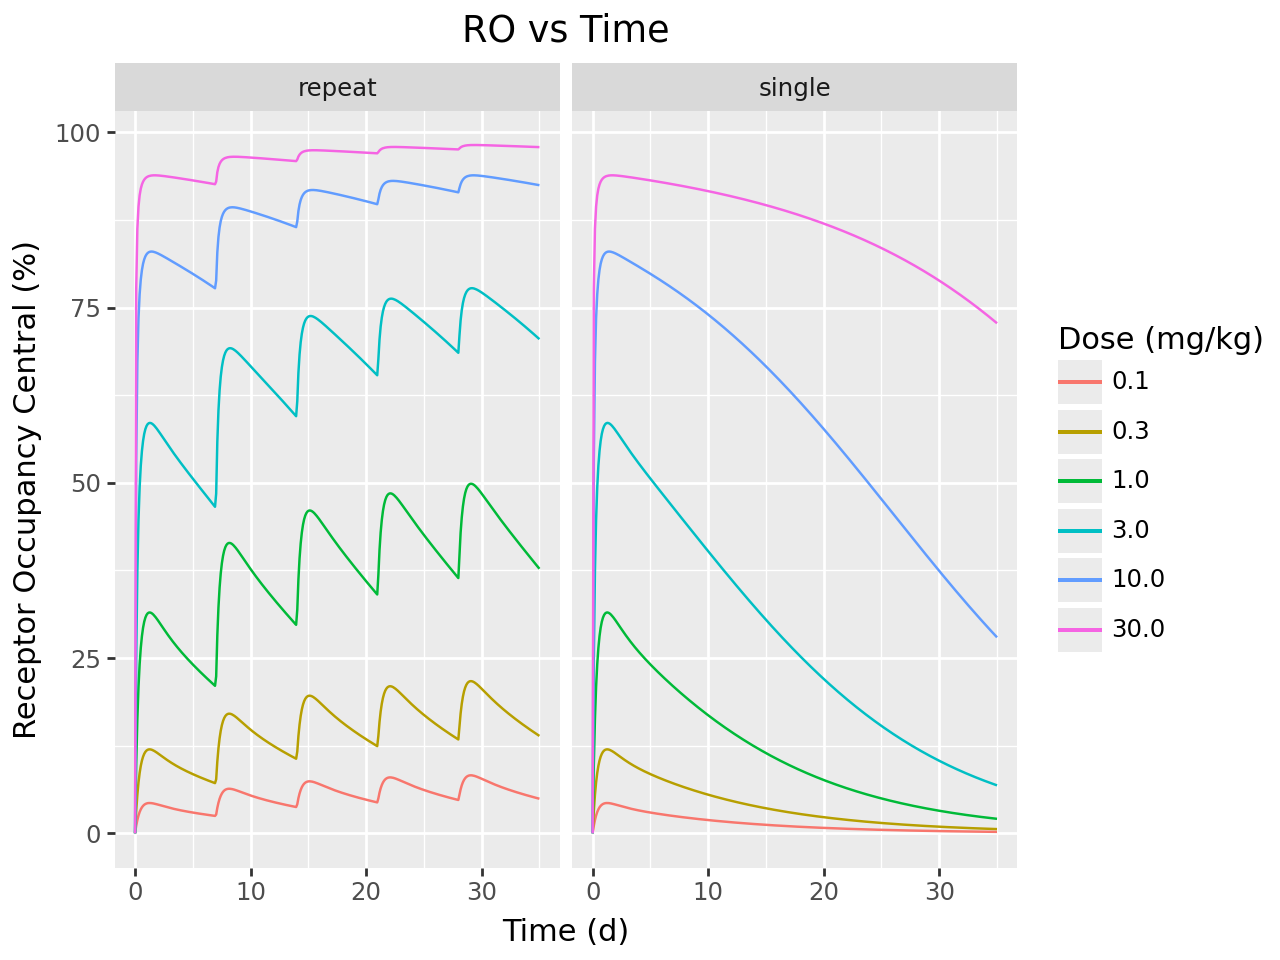

In [8]:
fig = (ggplot()
       + geom_line(data = Tres, mapping = aes(y = 'value', x = 't', color = 'factor(dose_mpk)'))
       + labs(x = 'Time (d)', y = 'Receptor Occupancy Central (%)', color = 'Dose (mg/kg)', title = 'RO vs Time')
       + facet_wrap('schedule')
)

display(fig)

### Two populations

In addition to adding labels to dose and simulation tables, it is possible to include a label column within the parameter table. This allows you to run simulations for multiple distinct populations simultaneously.

In the following example we will simulate both single and repeat dosing for two populations (one with fast clearance and one with slow clearance). Note, you can use a "\*" to denote that a row can be applied to all options of column values in a parameter or dose table. All desired combinations of labels must be explicitely written in the simulation table (No "\*"s)

In [9]:
Tpar

,parameter,unit,value,is_fit,upper_bound,lower_bound
0,Volume_c,L,3.000,False,NaN,NaN
1,Volume_p,L,13.000,False,NaN,NaN
2,MW,kDa,150.000,False,NaN,NaN
3,BW,kg,70.000,False,NaN,NaN
4,Pdist,1,0.300,False,NaN,NaN
5,Tdist,hr,7.000,False,NaN,NaN
6,Thalf,d,28.000,False,NaN,NaN
7,Receptors_c,nM,10.000,False,NaN,NaN
8,Receptors_p,nM,50.000,False,NaN,NaN
9,kon,1/nM/s,0.001,False,NaN,NaN


In [10]:
Tpar_2pop = Tpar.copy()
Tpar_2pop = pd.concat([Tpar_2pop.query('parameter != "Thalf"').assign(clearance = '*'),
                       Tpar_2pop.query('parameter == "Thalf"').assign(value = 14, clearance = 'fast'),
                       Tpar_2pop.query('parameter == "Thalf"').assign(value = 28, clearance = 'slow')])

Tdos_2pop = Tdos.copy().assign(clearance = '*')
Tsim_2pop = pd.concat([Tsim.copy().assign(clearance = 'slow'), Tsim.copy().assign(clearance = 'fast')])

In [11]:
print('Parameter Table:')
display(Tpar_2pop)
print('\nDose Table:')
display(Tdos_2pop)
print('\nSimulation Table:')
display(Tsim_2pop)

Parameter Table:


,parameter,unit,value,is_fit,upper_bound,lower_bound,clearance
0,Volume_c,L,3.000,False,NaN,NaN,*
1,Volume_p,L,13.000,False,NaN,NaN,*
2,MW,kDa,150.000,False,NaN,NaN,*
3,BW,kg,70.000,False,NaN,NaN,*
4,Pdist,1,0.300,False,NaN,NaN,*
5,Tdist,hr,7.000,False,NaN,NaN,*
7,Receptors_c,nM,10.000,False,NaN,NaN,*
8,Receptors_p,nM,50.000,False,NaN,NaN,*
9,kon,1/nM/s,0.001,False,NaN,NaN,*
10,Thalf_R,hr,60.000,False,NaN,NaN,*



Dose Table:


,dose_mpk,amounts,times,time_unit,amount_unit,route,schedule,clearance
0,0.1,0.1,"[0, 7, 14, 21, 28]",d,mg/kg,Dose_SC,repeat,*
1,0.3,0.3,"[0, 7, 14, 21, 28]",d,mg/kg,Dose_SC,repeat,*
2,1.0,1.0,"[0, 7, 14, 21, 28]",d,mg/kg,Dose_SC,repeat,*
3,3.0,3.0,"[0, 7, 14, 21, 28]",d,mg/kg,Dose_SC,repeat,*
4,10.0,10.0,"[0, 7, 14, 21, 28]",d,mg/kg,Dose_SC,repeat,*
5,30.0,30.0,"[0, 7, 14, 21, 28]",d,mg/kg,Dose_SC,repeat,*
0,0.1,0.1,[0],d,mg/kg,Dose_SC,single,*
1,0.3,0.3,[0],d,mg/kg,Dose_SC,single,*
2,1.0,1.0,[0],d,mg/kg,Dose_SC,single,*
3,3.0,3.0,[0],d,mg/kg,Dose_SC,single,*



Simulation Table:


,dose_mpk,schedule,clearance
0,0.1,repeat,slow
1,0.3,repeat,slow
2,1.0,repeat,slow
3,3.0,repeat,slow
4,10.0,repeat,slow
5,30.0,repeat,slow
0,0.1,single,slow
1,0.3,single,slow
2,1.0,single,slow
3,3.0,single,slow


In [12]:
Tres_2pop = abm.simulate(models = model,
                         parameters = Tpar_2pop,
                         doses = Tdos_2pop,
                         simulations = Tsim_2pop,
                         outputs = ['RO_c'],
                         times = abm.linspace(0,35,351,'d')).to_pandas(tall_outputs = True)

display(Tres_2pop.head())

Total: 0, Running: 0, Succeeded: 0, Failed: 0

,dose_mpk,schedule,clearance,id,t,output,value,output_unit
0,0.1,repeat,slow,0,0.0,RO_c,0.000000,1
1,0.1,repeat,slow,0,0.1,RO_c,1.071161,1
2,0.1,repeat,slow,0,0.2,RO_c,1.903999,1
3,0.1,repeat,slow,0,0.3,RO_c,2.548599,1
4,0.1,repeat,slow,0,0.4,RO_c,3.044722,1


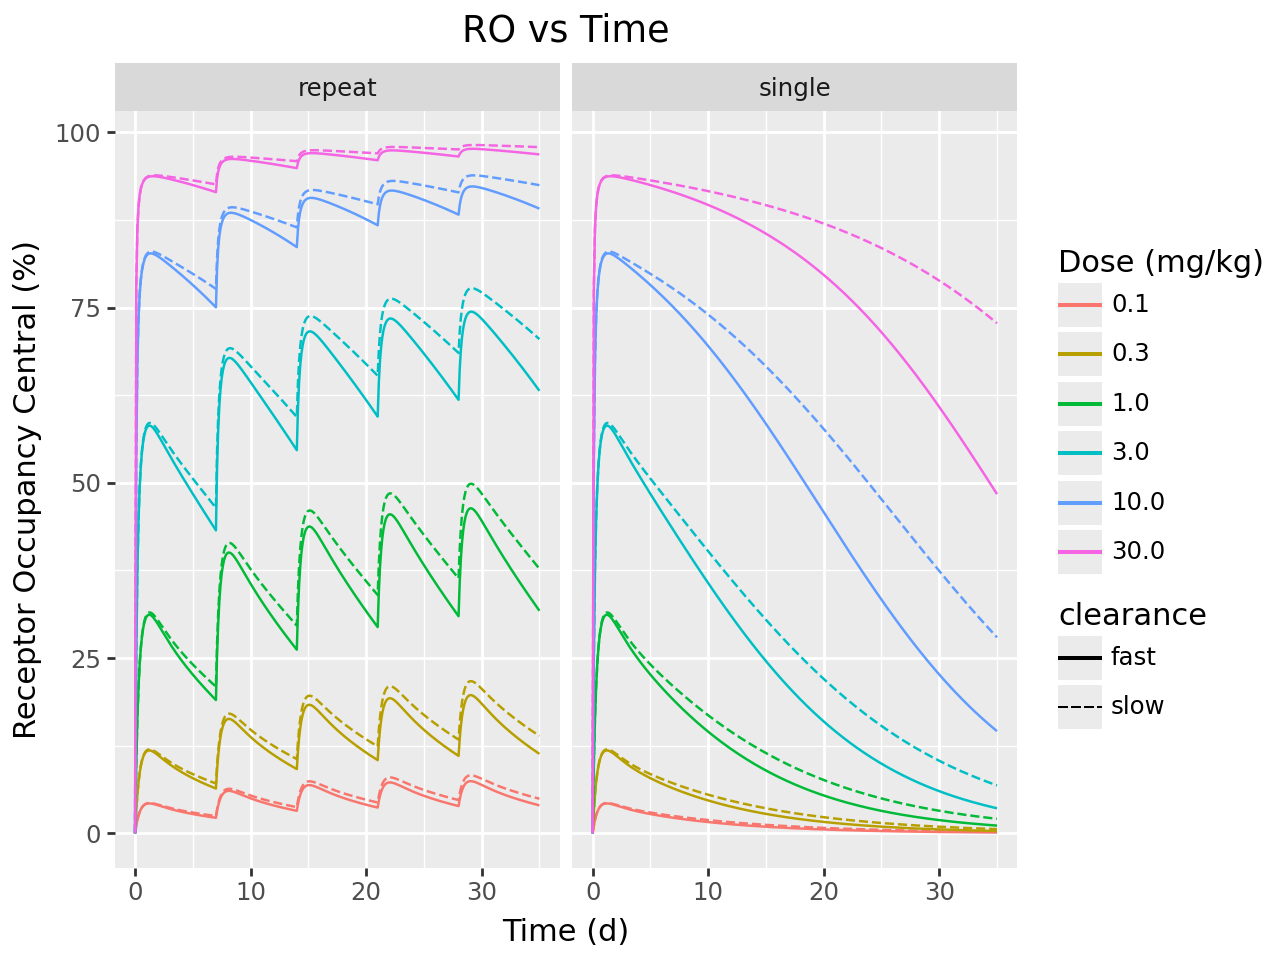

In [13]:
fig = (ggplot()
       + geom_line(data = Tres_2pop, mapping = aes(y = 'value', x = 't', color = 'factor(dose_mpk)',
                                                  linetype = 'clearance'))
       + labs(x = 'Time (d)', y = 'Receptor Occupancy Central (%)', color = 'Dose (mg/kg)', title = 'RO vs Time')
       + facet_wrap('schedule')
)

display(fig)

## Parameter scans

Another feature of the IQ Analyze Simulate function is the ability to run parameter scans. There are resources in repository demonstrating the way parameter scans can be combined. In this notebook we will focus on two examples of 1D parameter scans.

### Single parameter scan

In this example we will scan a single parameter (Affinity) over a two fold increase and decrease. We will see how the change in parameter value will affect the time dynamics of receptor occupancy as a function of this parameter change.

In [14]:
# grab one repeated dose for this example
Tsim_scan = Tsim.query('dose_mpk == 3 and schedule == "repeat"')
display(Tsim_scan)

,dose_mpk,schedule
3,3.0,repeat


In [15]:
# Fold scan over affinity
Tfold = abm.simulate(models = model,
                parameters = Tpar,
                doses = Tdos,
                simulations = Tsim_scan,
                outputs = ['RO_c'],
                times = abm.linspace(0,35,351,'d'),
                scans = abm.fold_scan(Kd = [0.5, 1, 2])).to_pandas(tall_outputs = True)

display(Tfold.head())

Total: 0, Running: 0, Succeeded: 0, Failed: 0

,dose_mpk,schedule,scan_0_type,id,param_scan_0,scan_0_value,scan_0_fold,t,output,value,output_unit
0,3.0,repeat,fold,0,Kd,45.0,0.5,0.0,RO_c,0.000000,1
1,3.0,repeat,fold,0,Kd,45.0,0.5,0.1,RO_c,38.861067,1
2,3.0,repeat,fold,0,Kd,45.0,0.5,0.2,RO_c,53.946938,1
3,3.0,repeat,fold,0,Kd,45.0,0.5,0.3,RO_c,61.486370,1
4,3.0,repeat,fold,0,Kd,45.0,0.5,0.4,RO_c,65.812745,1


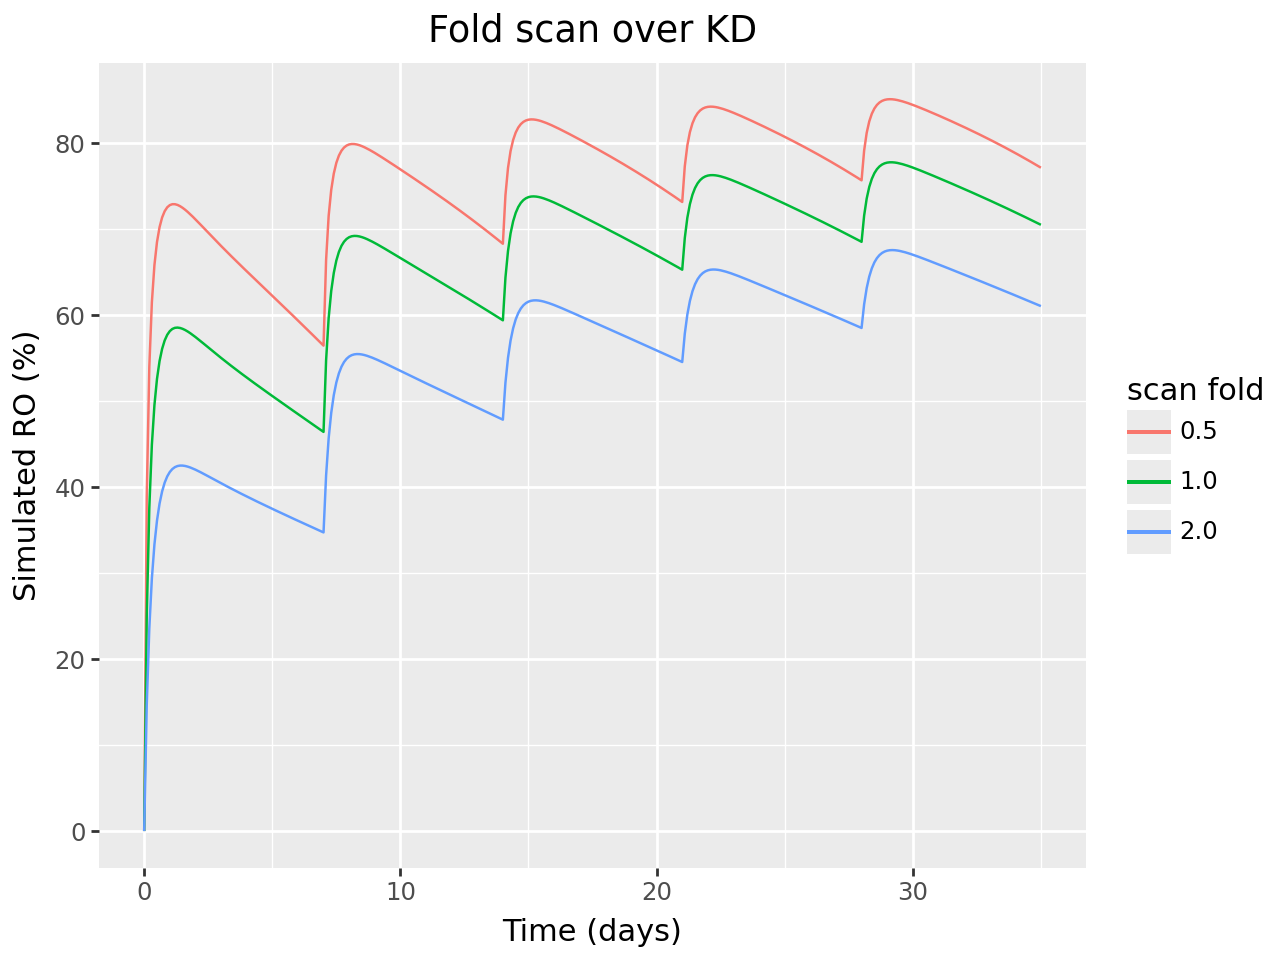

In [16]:
fig = (ggplot()
       + geom_line(data = Tfold, mapping = aes(x = 't', y = 'value', color = 'factor(scan_0_fold)'))
       + labs(x = 'Time (days)', y = 'Simulated RO (%)', color = 'scan fold', title = 'Fold scan over KD')
)

fig.show()

### One at a time sensitivity

In the following example we will perform a local sensitivity analysis by scanning 10 parameters (all except body weight and molecular weight). The output of this block of code will be a tornado plot which shows how the desired summary statistic (terminal RO in this case) responds to changes in each of the parameters.

In [17]:
Tsens = abm.simulate(models = model,
        parameters = Tpar,
        doses = Tdos,
        simulations = Tsim_scan,
        outputs = ['RO_c'],
        times = ['35:d'],
        scans = abm.fold_scan(Volume_c = [0.5, 1, 2])
                 + abm.fold_scan(Volume_p = [0.5, 1, 2])
                 + abm.fold_scan(kon = [0.5, 1, 2])
                 + abm.fold_scan(Kd = [0.5, 1, 2])
                 + abm.fold_scan(Thalf = [0.5, 1, 2])
                 + abm.fold_scan(Thalf_R = [0.5, 1, 2])
                 + abm.fold_scan(Pdist = [0.5, 1, 2])
                 + abm.fold_scan(Tdist = [0.5, 1, 2])
                 + abm.fold_scan(Receptors_c = [0.5, 1, 2])
                 + abm.fold_scan(Receptors_p = [0.5, 1, 2])
                 + abm.fold_scan(F = [0.5, 1, 2])
                 + abm.fold_scan(Thalf_abs = [0.5, 1, 2])
                ).to_pandas(tall_outputs = True)

Total: 0, Running: 0, Succeeded: 0, Failed: 0

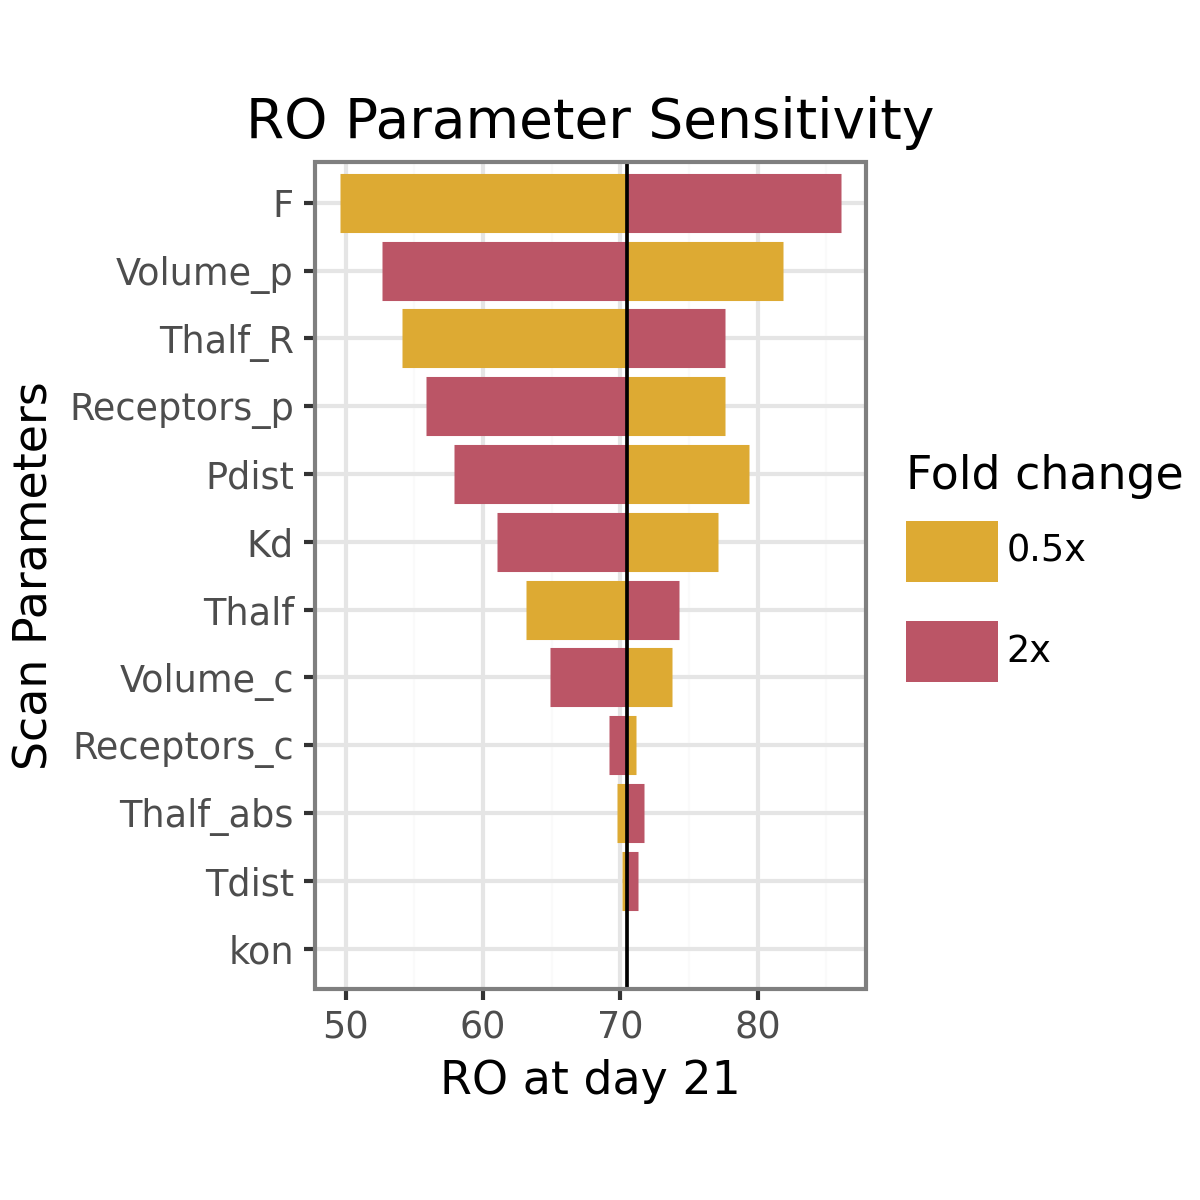

In [18]:
# Get the nominal output value
nominal_value = Tsens.value[Tsens.scan_0_fold == 1.].reset_index(drop = True)[0]

# Get table with parameters ordered as they should appear in the tornado plot
par_ranges = (
    Tsens
    .groupby('param_scan_0') # For each parameter...
    ['value'] # ...take the value column...
    .apply(lambda val: max(val)-min(val)) # ...and calculate the difference between the max and min value
    .sort_values() # Sort parameters by the result
)
ordered_pars = par_ranges.index.tolist()

# Construct the plot
(
    ggplot(Tsens.query('scan_0_fold != 1'))
    
    # Colored segments connecting the points
    + geom_segment(
        aes(x='value', xend='nominal_value', 
            y='param_scan_0', yend='param_scan_0',
            color = 'factor(scan_0_fold)'),
        size = 8
    )
    
    
    # Nominal line
    + geom_vline(xintercept = nominal_value)
    
    # Set colors and their labels
    + scale_color_manual(
        values = ['#DDAA33', '#BB5566'],
        labels = lambda xs: [f"{xi:g}x" for xi in xs] # Function converts list of numbers to "{number}x"
    )
    
    # Order the parameters for the "tornado" shape
    + scale_y_discrete(limits = ordered_pars) # For a discrete scale, setting limits sets the order of values
    
    + labs(x = "RO at day 21", y = "Scan Parameters", color = "Fold change",
           title = "RO Parameter Sensitivity")
    + theme_bw()
    + theme(aspect_ratio = 1.5, dpi=150, figure_size = (4,4))
)

## Optimization

The IQ Analyze allows access to state of the art optimization algorithms for systems models.

In the following example we will plot data, demonstrate the simulations given by the nominal parameter set, run an optimization to the data, and then demonstrate the simulations given by the optimized parameter set.

There are more details in other examples within this repository on how exactly to set up optimizations.

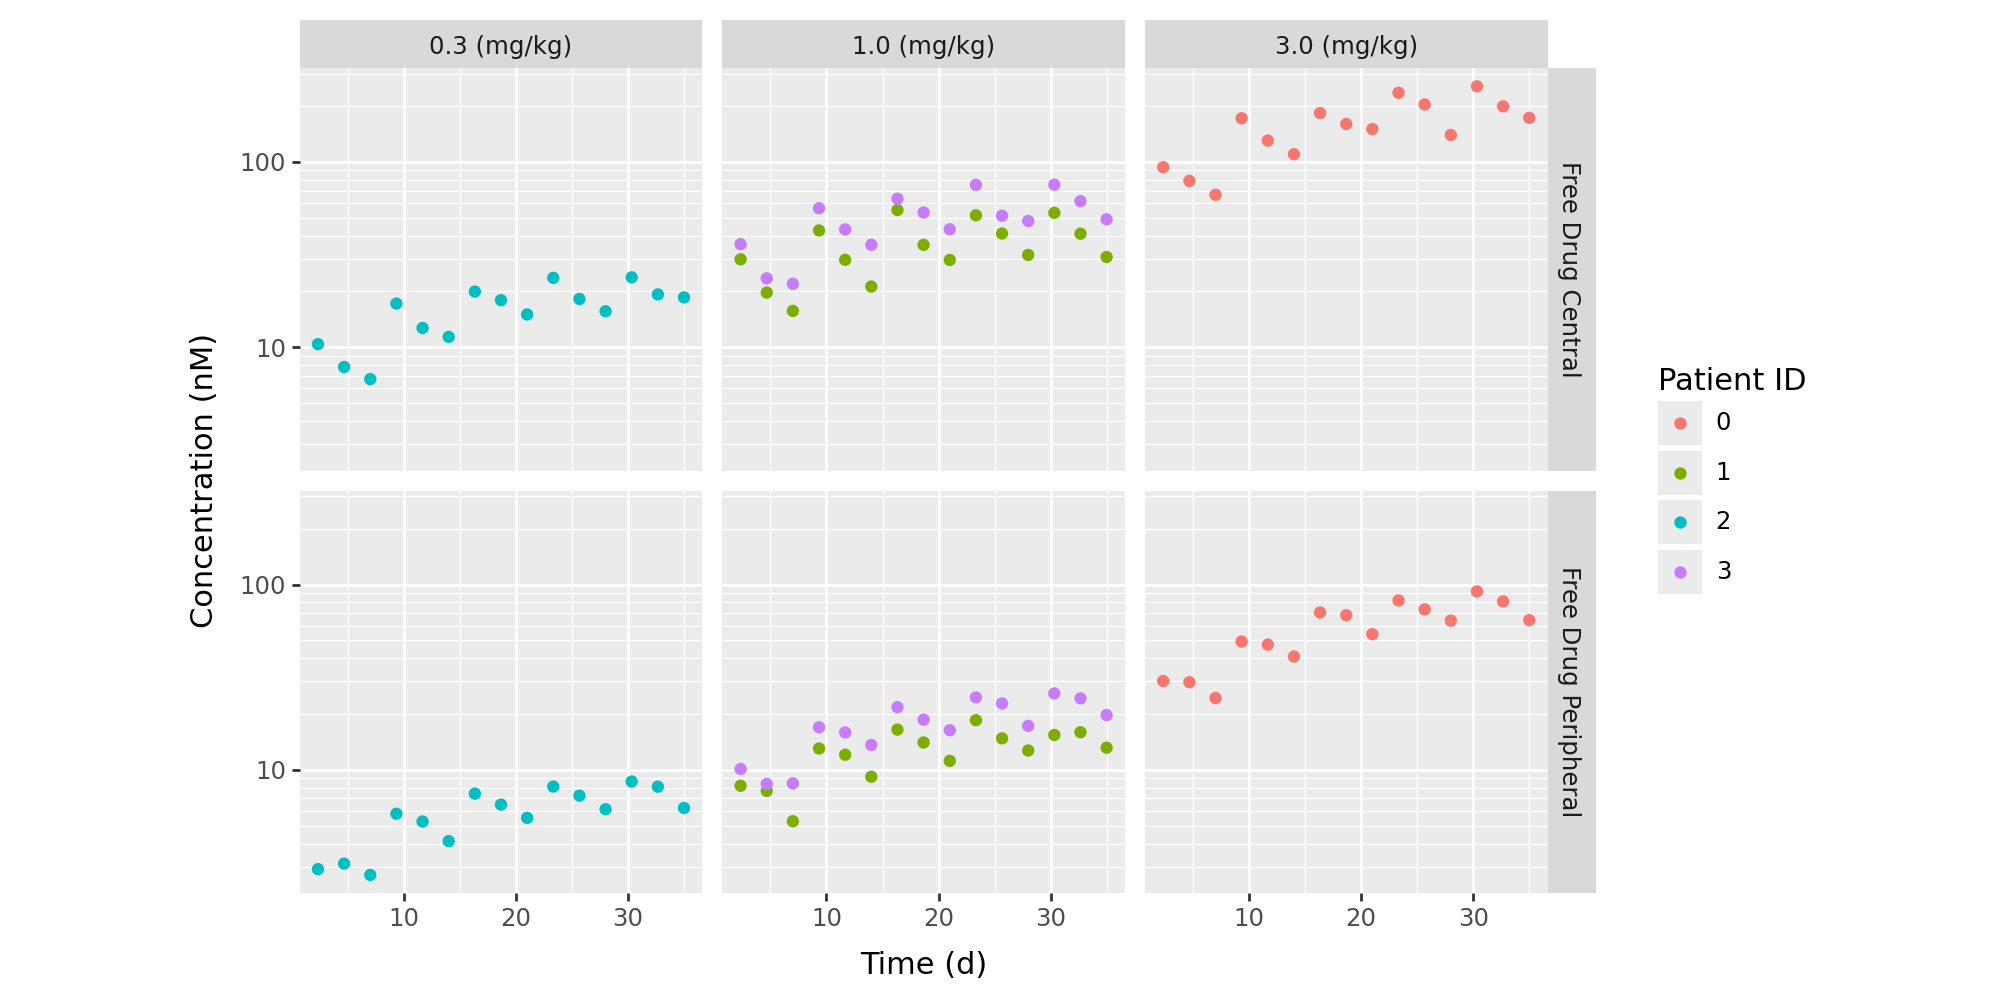

In [19]:
data = pd.read_csv('inputs/Data/Data_example_subset.csv')
data = data.query('time > 0')

output_dict = {'free_drug_c': 'Free Drug Central',
               'free_drug_p': 'Free Drug Peripheral'}

def label_data(x):
    if '.' in x:
        return f'{x} (mg/kg)'
    else:
        return output_dict[x]

fig = (ggplot()
       + geom_point(data = data, mapping = aes(x = 'time', y = 'measurement', color = 'factor(ID)'))
       + facet_grid('output ~ dose_mpk', labeller = lambda x: label_data(x))
       + scale_y_log10(breaks = 10.**np.arange(-20,20,1))
       + labs(y = 'Concentration (nM)', x = 'Time (d)', color = 'Patient ID')
       + theme(aspect_ratio = 1, figure_size = (10,5))
      )

display(fig)

In [20]:
fit_same = ['Thalf','Pdist']
fit_diff = ['Receptors_c', 'Receptors_p']
ID_list = [0,1,2,3]

Tpar_prefit = Tpar.copy()
Tpar_prefit = pd.concat([Tpar.query(f'not ((parameter.isin({fit_same})) or (parameter.isin({fit_diff})))').assign(ID = '*'),
                         Tpar.query(f'parameter.isin({fit_same})').assign(ID = '*', upper_bound = lambda x: x.value * 100,
                                                                          lower_bound = lambda x: x.value * 0.01, is_fit = True),
                         pd.concat([Tpar.query(f'parameter.isin({fit_diff})').assign(ID = i, upper_bound = lambda x: x.value * 100,
                                                                          lower_bound = lambda x: x.value * 0.01, is_fit = True)\
                                    for i in ID_list])
                        ])

In [21]:
print('Parameter Table - to fit:')
display(Tpar_prefit.query('is_fit == True'))

Parameter Table - to fit:


,parameter,unit,value,is_fit,upper_bound,lower_bound,ID
4,Pdist,1,0.3,True,30.0,0.003,*
6,Thalf,d,28.0,True,2800.0,0.280,*
7,Receptors_c,nM,10.0,True,1000.0,0.100,0
8,Receptors_p,nM,50.0,True,5000.0,0.500,0
7,Receptors_c,nM,10.0,True,1000.0,0.100,1
8,Receptors_p,nM,50.0,True,5000.0,0.500,1
7,Receptors_c,nM,10.0,True,1000.0,0.100,2
8,Receptors_p,nM,50.0,True,5000.0,0.500,2
7,Receptors_c,nM,10.0,True,1000.0,0.100,3
8,Receptors_p,nM,50.0,True,5000.0,0.500,3


In [22]:
Tdos_fit = Tdos.copy().assign(ID = '*', dose_route = 'Dose_SC').query('schedule == "repeat"')

In [23]:
print('Dose Table for individuals:')
display(Tdos_fit)

Dose Table for individuals:


,dose_mpk,amounts,times,time_unit,amount_unit,route,schedule,ID,dose_route
0,0.1,0.1,"[0, 7, 14, 21, 28]",d,mg/kg,Dose_SC,repeat,*,Dose_SC
1,0.3,0.3,"[0, 7, 14, 21, 28]",d,mg/kg,Dose_SC,repeat,*,Dose_SC
2,1.0,1.0,"[0, 7, 14, 21, 28]",d,mg/kg,Dose_SC,repeat,*,Dose_SC
3,3.0,3.0,"[0, 7, 14, 21, 28]",d,mg/kg,Dose_SC,repeat,*,Dose_SC
4,10.0,10.0,"[0, 7, 14, 21, 28]",d,mg/kg,Dose_SC,repeat,*,Dose_SC
5,30.0,30.0,"[0, 7, 14, 21, 28]",d,mg/kg,Dose_SC,repeat,*,Dose_SC


In [24]:
opt = abm.optimize(measurements = data,
             parameters = Tpar_prefit,
             doses = Tdos_fit,
             models = model)

Total: 0, Running: 0, Succeeded: 0, Failed: 0

iteration,objective,Receptors_c_fit_14,Receptors_p_fit_15,Pdist_fit_12,Thalf_fit_13,Receptors_c_fit_16,Receptors_p_fit_17,Receptors_c_fit_18,Receptors_p_fit_19,Receptors_c_fit_20,Receptors_p_fit_21
0,140.676566,10.000000,50.000000,0.300000,28.000000,10.000000,50.000000,10.000000,50.000000,10.000000,50.000000
1,140.676566,10.000000,50.000000,0.300000,28.000000,10.000000,50.000000,10.000000,50.000000,10.000000,50.000000
2,-216.810994,10.065462,51.717676,0.466072,27.185772,10.367382,63.065446,9.688326,41.700894,9.920627,47.574013
3,-451.487014,9.616257,47.350842,0.363274,30.625098,13.683278,80.707270,8.758743,35.049252,9.186236,41.638660
4,-489.540615,10.414477,53.940878,0.429600,43.809804,12.279300,66.847419,7.585733,29.056171,9.468194,43.162418
5,-511.506751,10.621252,57.367779,0.403152,42.354491,12.431809,71.985519,7.632560,30.485940,9.565654,44.377688
6,-511.506751,10.621252,57.367779,0.403152,42.354491,12.431809,71.985519,7.632560,30.485940,9.565654,44.377688
7,-517.230813,10.576233,55.191821,0.411304,41.962520,12.484323,74.111129,7.685899,31.726098,9.579532,44.825175
8,-517.230813,10.576233,55.191821,0.411304,41.962520,12.484323,74.111129,7.685899,31.726098,9.579532,44.825175
9,-518.665232,10.561366,54.887193,0.405474,41.950347,12.489907,73.813047,7.700351,31.920240,9.570337,44.725987


In [25]:
Tfit = opt.simulate(times = abm.linspace(0,35, 351,'d')).to_pandas(tall_outputs = True)

Total: 0, Running: 0, Succeeded: 0, Failed: 0

/home/jovyan/environment/.pixi/envs/default/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10


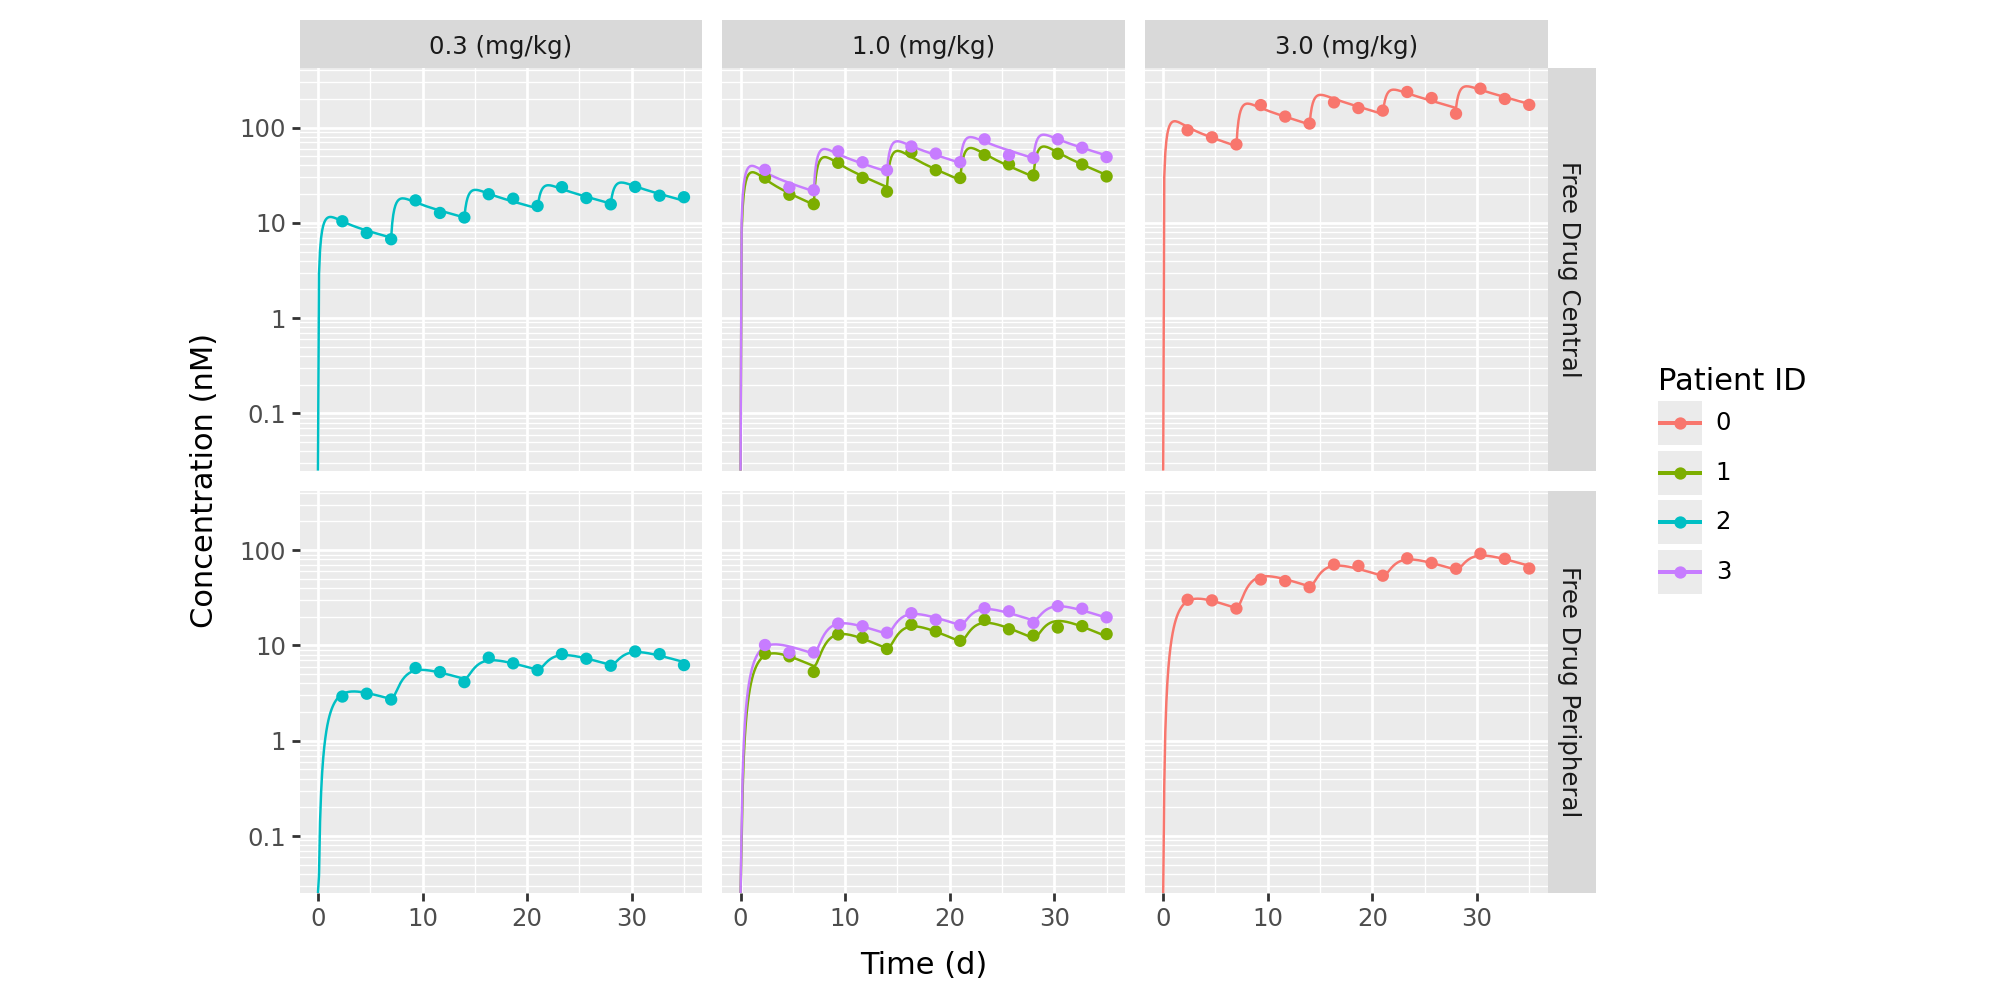

In [26]:
fig = (ggplot()
       + geom_line(data = Tfit, mapping = aes(x = 't', y = 'value', color = 'factor(ID)'))
       + geom_point(data = data, mapping = aes(x = 'time', y = 'measurement', color = 'factor(ID)'))
       + facet_grid('output ~ dose_mpk', labeller = lambda x: label_data(x))
       + scale_y_log10(breaks = 10.**np.arange(-20,20,1))
       + labs(y = 'Concentration (nM)', x = 'Time (d)', color = 'Patient ID')
       + theme(aspect_ratio = 1, figure_size = (10,5))
      )

display(fig)

In [27]:
Tpar_fit = opt.fit_parameter_table.to_pandas()
print('Final Fitted Parameters:')
display(Tpar_fit.query('is_fit == True'))

Final Fitted Parameters:


,parameter,unit,value,is_fit,upper_bound,lower_bound,ID,global_parameter_name
12,Pdist,1,0.400152,True,30.0,0.003,*,Pdist_fit_12
13,Thalf,d,30.676496,True,2800.0,0.280,*,Thalf_fit_13
14,Receptors_c,nM,7.883158,True,1000.0,0.100,0,Receptors_c_fit_14
15,Receptors_p,nM,51.351229,True,5000.0,0.500,0,Receptors_p_fit_15
16,Receptors_c,nM,35.410616,True,1000.0,0.100,1,Receptors_c_fit_16
17,Receptors_p,nM,56.946521,True,5000.0,0.500,1,Receptors_p_fit_17
18,Receptors_c,nM,10.085668,True,1000.0,0.100,2,Receptors_c_fit_18
19,Receptors_p,nM,28.396467,True,5000.0,0.500,2,Receptors_p_fit_19
20,Receptors_c,nM,0.100255,True,1000.0,0.100,3,Receptors_c_fit_20
21,Receptors_p,nM,46.618630,True,5000.0,0.500,3,Receptors_p_fit_21
